In [17]:
import pandas as pd
import os
import pickle
import numpy as np

OUTPUT_PATH = r"C:\Users\ASUS\Desktop\Coding\Data Science Projects\customer_complaint\outputs"

X_train = pd.read_csv(
    os.path.join(OUTPUT_PATH, "X_train.csv")
)["text"]

X_val = pd.read_csv(
    os.path.join(OUTPUT_PATH, "X_val.csv")
)["text"]

X_test = pd.read_csv(
    os.path.join(OUTPUT_PATH, "X_test.csv")
)["text"]

y_train = pd.read_csv(
    os.path.join(OUTPUT_PATH, "y_train.csv")
)["label"]

y_val = pd.read_csv(
    os.path.join(OUTPUT_PATH, "y_val.csv")
)["label"]

y_test = pd.read_csv(
    os.path.join(OUTPUT_PATH, "y_test.csv")
)["label"]

with open(
    os.path.join(OUTPUT_PATH, "label_encoder.pkl"),
    "rb"
) as f:
    label_encoder = pickle.load(f)

print("Data loaded successfully!")
print()
print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))
print("Classes    :", len(label_encoder.classes_))

Data loaded successfully!

Train      : 234844
Validation : 58712
Test       : 73389
Classes    : 11


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=50000,
    sublinear_tf=True
)

print("TF-IDF vectorizer created.")

TF-IDF vectorizer created.


In [5]:
X_train_tfidf = tfidf.fit_transform(X_train)

print("Training TF-IDF shape:", X_train_tfidf.shape)

Training TF-IDF shape: (234844, 50000)


In [6]:
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Validation shape:", X_val_tfidf.shape)
print("Test shape      :", X_test_tfidf.shape)

Validation shape: (58712, 50000)
Test shape      : (73389, 50000)


In [8]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression trained successfully.")


Logistic Regression trained successfully.


In [9]:
y_val_pred = lr_model.predict(X_val_tfidf)

print("Validation predictions generated.")

Validation predictions generated.


In [10]:
accuracy = accuracy_score(y_val, y_val_pred)

precision = precision_score(
    y_val,
    y_val_pred,
    average="macro"
)

recall = recall_score(
    y_val,
    y_val_pred,
    average="macro"
)

f1 = f1_score(
    y_val,
    y_val_pred,
    average="macro"
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"Macro F1  : {f1:.4f}")

Accuracy  : 0.8268
Precision : 0.6730
Recall    : 0.7509
Macro F1  : 0.7042


In [11]:
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=label_encoder.classes_,
        digits=4
    )
)

                  precision    recall  f1-score   support

    bank_account     0.8131    0.8351    0.8239      4433
     credit_card     0.7798    0.8293    0.8038      6402
credit_reporting     0.9104    0.8016    0.8525     17637
 debt_collection     0.8486    0.8211    0.8346     13485
            loan     0.5091    0.6204    0.5592      2492
  money_transfer     0.6955    0.8215    0.7533      1115
        mortgage     0.9157    0.9357    0.9256      8471
           other     0.2000    0.2553    0.2243        47
    prepaid_card     0.5200    0.7845    0.6254       232
    student_loan     0.8369    0.9030    0.8687      3484
    vehicle_loan     0.3737    0.6521    0.4751       914

        accuracy                         0.8268     58712
       macro avg     0.6730    0.7509    0.7042     58712
    weighted avg     0.8394    0.8268    0.8308     58712



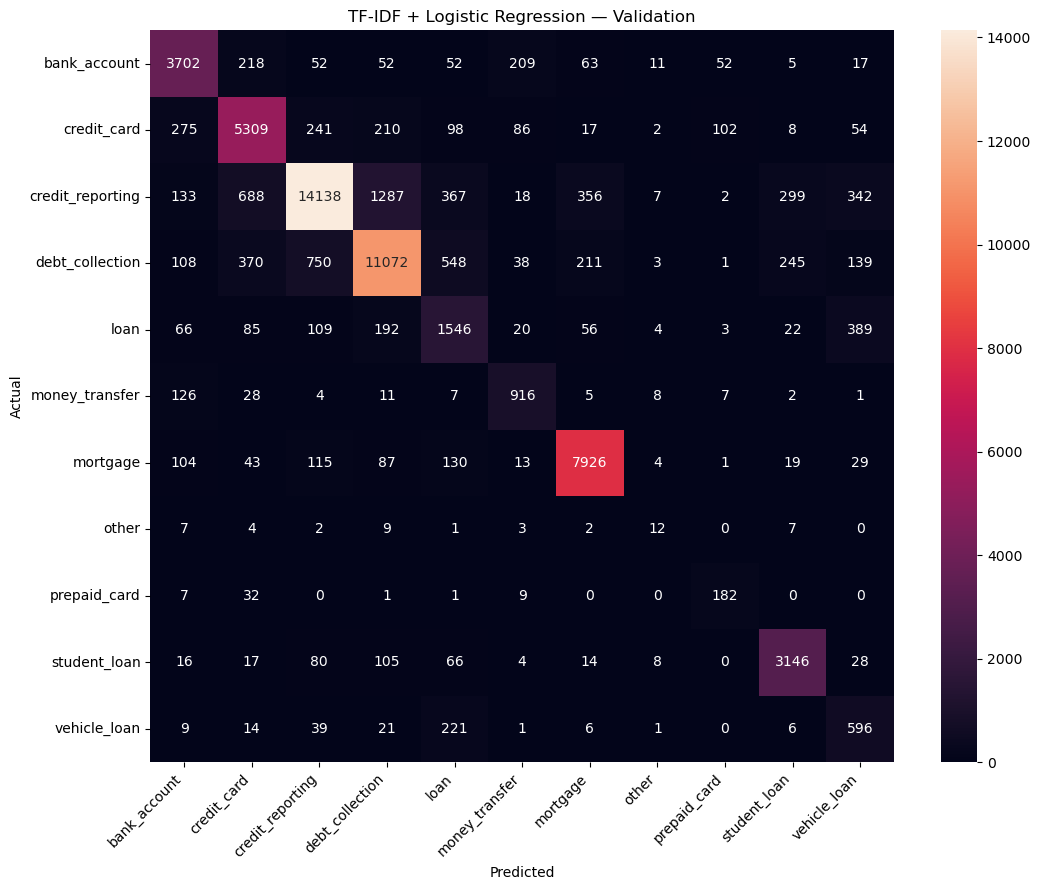

In [12]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("TF-IDF + Logistic Regression — Validation")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [13]:
results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Accuracy": [accuracy],
    "Macro Precision": [precision],
    "Macro Recall": [recall],
    "Macro F1": [f1]
})

results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TF-IDF + Logistic Regression,0.826833,0.672976,0.750862,0.704225


In [14]:
report = classification_report(
    y_val,
    y_val_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

class_performance = pd.DataFrame(report).T

class_performance[
    ["precision", "recall", "f1-score", "support"]
].sort_values("recall")

,precision,recall,f1-score,support
other,0.200000,0.255319,0.224299,47.000000
loan,0.509055,0.620385,0.559233,2492.000000
vehicle_loan,0.373668,0.652079,0.475090,914.000000
macro avg,0.672976,0.750862,0.704225,58712.000000
prepaid_card,0.520000,0.784483,0.625430,232.000000
credit_reporting,0.910367,0.801610,0.852534,17637.000000
debt_collection,0.848624,0.821060,0.834615,13485.000000
money_transfer,0.695520,0.821525,0.753289,1115.000000
weighted avg,0.839432,0.826833,0.830829,58712.000000
accuracy,0.826833,0.826833,0.826833,0.826833


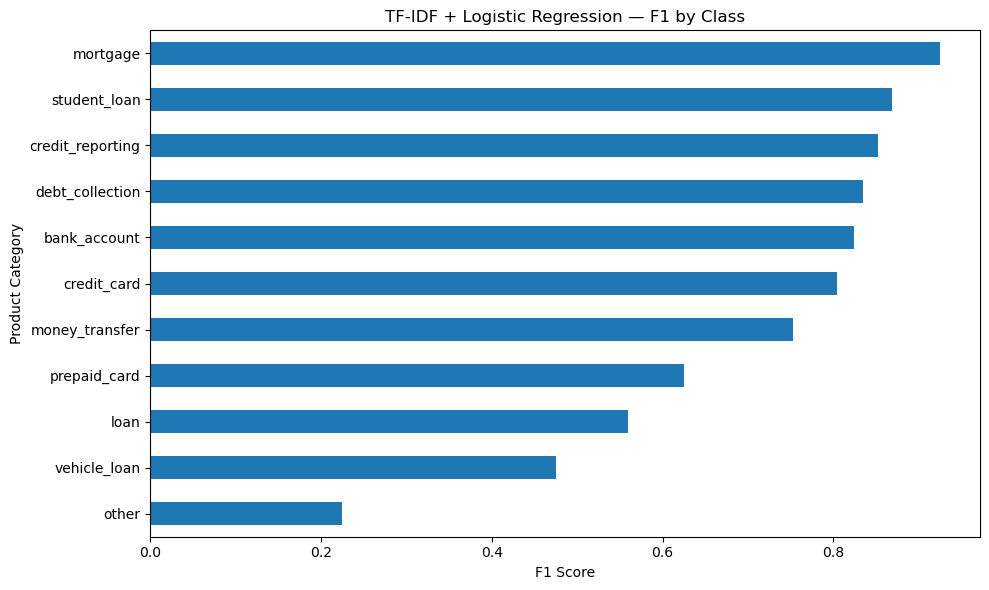

In [15]:
class_f1 = class_performance.loc[
    label_encoder.classes_,
    "f1-score"
].sort_values()

plt.figure(figsize=(10, 6))

class_f1.plot(kind="barh")

plt.title("TF-IDF + Logistic Regression — F1 by Class")
plt.xlabel("F1 Score")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

In [18]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_df = pd.DataFrame({
    "Class": classes,
    "Category": label_encoder.inverse_transform(classes),
    "Weight": class_weights
})


class_weight_df

,Class,Category,Weight
0,0,bank_account,1.203871
1,1,credit_card,0.833637
2,2,credit_reporting,0.302619
3,3,debt_collection,0.395822
4,4,loan,2.141799
5,5,money_transfer,4.787947
6,6,mortgage,0.630131
7,7,other,114.782014
8,8,prepaid_card,23.055566
9,9,student_loan,1.531744


In [19]:
import os
import pickle

MODEL_PATH = r"C:\Users\ASUS\Desktop\Coding\Data Science Projects\customer_complaint\models"

os.makedirs(MODEL_PATH, exist_ok=True)

with open(
    os.path.join(MODEL_PATH, "tfidf_vectorizer.pkl"),
    "wb"
) as f:
    pickle.dump(tfidf, f)

print("TF-IDF vectorizer saved.")

TF-IDF vectorizer saved.


In [20]:
with open(
    os.path.join(MODEL_PATH, "logistic_regression.pkl"),
    "wb"
) as f:
    pickle.dump(lr_model, f)

print("Logistic Regression model saved.")

Logistic Regression model saved.
